In [185]:
#Designing a Scalable Canadian Real Estate Data Pipeline

LOAD

In [186]:
#Importing the Required Libraries
import pandas as pd
import numpy as np

#Loading the Dataset
df = pd.read_csv("rentaldb_ca.csv")

#Viewing first few rows
df.head()

,id,price_cad,square_feet,bedrooms,bathrooms,cityname,province,latitude,longitude,amenities,posted_date,building_type
0,1,1479.91,903.0,1,1,Edmonton,Alberta,53.548431,-113.492620,"Laundry, Gym, Parking",2025-12-26,Basement
1,2,2014.63,706.0,2,1,Mississauga,Ontario,43.574237,-79.629230,"Pet Friendly, Gym",2025-07-07,Basement
2,3,2382.25,822.0,1,1,Vancouver,British Columbia,49.272484,-123.122318,"Balcony, Pool, Pet Friendly, Parking",2025-09-22,Condo
3,4,2229.02,555.0,2,2,Montreal,Quebec,45.492628,-73.555414,"Parking, Pet Friendly, Gym",2025-02-13,Condo
4,5,NaN,805.0,1,2,Edmonton,Alberta,53.527343,-113.507468,"Pet Friendly, Pool, Laundry, Parking",2025-06-06,Townhouse


Proposed Schema (Fields, Types, Rationales:
Id 	
Integer 	Unique identifier for each rental listing. Ensures each record can be uniquely referenced.

price_cad	
Float	Monthly rent in Canadian dollars (CAD). Important for analysis, comparisons, and modeling.

square_feet	
Integer 	Size of the property. Helps determine price per square foot and property value.

bedrooms	
Integer	Number of bedrooms. Key feature influencing rental price and tenant preference.

Bathrooms	
Integer	Number of bathrooms. Impacts usability and pricing.

cityname	
String	City where the property is located (e.g., Toronto, Vancouver). Important for geographic analysis

Province	
String	Canadian province (e.g., Ontario, Alberta). Useful for regional comparisons and policy insights

Latitude	
Float	Geographic coordinate for mapping and spatial analysis.

Longitude	
Float	Geographic coordinate for mapping and clustering

amenities	
String	List of features (e.g., Parking, Gym). Useful for feature engineering and desirability scoring.

posted_date	
String	Date when listing was posted. Enables time-series analysis and trend tracking.

building_type	
String	Type of property (Apartment, Condo, Townhouse, Basement). Helps segment the market.




Inspect

In [187]:
#Check the datatype and null values in our dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             250 non-null    int64  
 1   price_cad      242 non-null    float64
 2   square_feet    243 non-null    float64
 3   bedrooms       250 non-null    int64  
 4   bathrooms      250 non-null    int64  
 5   cityname       250 non-null    object 
 6   province       250 non-null    object 
 7   latitude       250 non-null    float64
 8   longitude      250 non-null    float64
 9   amenities      250 non-null    object 
 10  posted_date    250 non-null    object 
 11  building_type  250 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 23.6+ KB


In [188]:
#Find Statistical Summary
df.describe()

,id,price_cad,square_feet,bedrooms,bathrooms,latitude,longitude
count,250.000000,242.000000,243.000000,250.000000,250.000000,250.000000,250.000000
mean,125.500000,2066.341983,835.798354,1.924000,1.528000,47.849868,-94.999469
std,72.312977,590.724378,200.220675,0.820314,0.500217,3.153585,20.349839
min,1.000000,652.260000,243.000000,1.000000,1.000000,43.565644,-123.146610
25%,63.250000,1664.435000,702.000000,1.000000,1.000000,45.419187,-114.070013
50%,125.500000,2049.915000,839.000000,2.000000,2.000000,49.173715,-97.120509
75%,187.750000,2393.317500,976.500000,3.000000,2.000000,49.901992,-75.689835
max,250.000000,4630.410000,1397.000000,3.000000,2.000000,53.570894,-71.190959


In [189]:
#Check the missing Values
df.isnull().sum()

id               0
price_cad        8
square_feet      7
bedrooms         0
bathrooms        0
cityname         0
province         0
latitude         0
longitude        0
amenities        0
posted_date      0
building_type    0
dtype: int64

Data Privacy:
Overall, the dataset is quite safe since it does not include any personal or sensitive information such as name, email, phone numbers, exact addresses, dob, payment info, SIN Number etc. The only column that might pose some data privacy risks is the latitudes and longitudes column since it contains the exact location data which can pose some privacy risk and to encapsulate that we can use some data abstraction techniques to avoid using the exact latitudes and longitudes to preserve the client privacy.
Below are some of the mentioned techniques that could be used:
a.	Show data at neighborhood or city level, not exact coordinates
b.	Restrict raw location data to authorized users only
c.	Hide precise coordinates in public datasets


Clean

In [190]:
#Standardize City and Province Name to fix inconsistencies e.g "toronto" vs "Toronto"
#.str.strip() removes the extra spaces 
#.str.title() converts into Title format e.g first letter in UpperCase and the others smallcase
#.str.lower() 
df['cityname'] = df['cityname'].str.strip().str.title()
df['province'] = df['province'].str.strip().str.title()

#Standarardize the building Type
df['building_type'] = df['building_type'].str.strip().str.title()

#Standardize the Amenities 
#Making it All  Lowercase for consistency
df['amenities'] = df['amenities'].str.lower().str.strip()


In [191]:
#Converting Numeric columns and ensuring numbers are actually numeric
df['price_cad'] = pd.to_numeric(df['price_cad'], errors='coerce')
df['square_feet'] = pd.to_numeric(df['square_feet'], errors='coerce')

#Converting date column to the correct date format, this allows for time-based analysis
df['posted_date'] = pd.to_datetime(df['posted_date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             250 non-null    int64         
 1   price_cad      242 non-null    float64       
 2   square_feet    243 non-null    float64       
 3   bedrooms       250 non-null    int64         
 4   bathrooms      250 non-null    int64         
 5   cityname       250 non-null    object        
 6   province       250 non-null    object        
 7   latitude       250 non-null    float64       
 8   longitude      250 non-null    float64       
 9   amenities      250 non-null    object        
 10  posted_date    250 non-null    datetime64[ns]
 11  building_type  250 non-null    object        
dtypes: datetime64[ns](1), float64(4), int64(3), object(4)
memory usage: 23.6+ KB


In [192]:
#Handling Missing Values
#Looking at our dataset, we noticed that the square feet columns has 7 missing values and price_cad has 8 missing values
#Replacing the missing values in square feet and price with the median
#We are replacing the missing values in price and sqaure feet with Median since it performs better and is less affected by the outliers 
#This helps keep our dataset as accurate and realistic as possible 
df['square_feet'].fillna(df['square_feet'].median(), inplace=True)
df['price_cad'].fillna(df['price_cad'].median(), inplace=True)

#Verifying that there are no missing values anymore
df.isnull().sum()

#Handling Outliers 
#Removing extreme outliers using the IQR Method to remove noise
q1=df['price_cad'].quantile(0.25)
q3=df['price_cad'].quantile(0.75)
iqr= q3-q1

lower_bound= q1-(1.5*iqr)
upper_bound= q3+(1.5*iqr)

df=df[(df['price_cad'] >= lower_bound) & (df['price_cad'] <= upper_bound)]

#Getting the Numerical Stats
print(df.describe())

#Grouping by City (To get the Average Rent)
city_avg = df.groupby('cityname')['price_cad'].mean().sort_values(ascending=False)
print(city_avg)

#Find the Bedrooms Distribution
print(df['bedrooms'].value_counts())




               id    price_cad  square_feet    bedrooms   bathrooms  \
count  246.000000   246.000000   246.000000  246.000000  246.000000   
mean   125.422764  2033.701870   833.784553    1.918699    1.532520   
min      1.000000   652.260000   243.000000    1.000000    1.000000   
25%     63.250000  1676.587500   703.250000    1.000000    1.000000   
50%    125.500000  2049.915000   839.000000    2.000000    2.000000   
75%    187.750000  2379.280000   974.000000    3.000000    2.000000   
max    250.000000  3411.390000  1397.000000    3.000000    2.000000   
std     72.457899   525.065222   198.111467    0.819094    0.499959   

         latitude   longitude                    posted_date  
count  246.000000  246.000000                            246  
mean    47.852677  -95.041694  2025-07-08 06:55:36.585365760  
min     43.565644 -123.146610            2025-01-01 00:00:00  
25%     45.419688 -114.071780            2025-04-12 12:00:00  
50%     49.173715  -97.120509            2025

C:\Users\ashab\AppData\Local\Temp\ipykernel_29080\3257134416.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['square_feet'].fillna(df['square_feet'].median(), inplace=True)
C:\Users\ashab\AppData\Local\Temp\ipykernel_29080\3257134416.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

Algorithms: Solving the Product Team’s Problem

Linear Search by Price

In [193]:
def linear_search_price(data, target_price):
    results=[]
    n = len(data)

    for i in range(n):
        if int (data.iloc[i]['price_cad']) == target_price:
            results.append(data.iloc[i])

    return results

#Example Test
results = linear_search_price(df,2014)
print(results)

[id                                 2
price_cad                    2014.63
square_feet                    706.0
bedrooms                           2
bathrooms                          1
cityname                 Mississauga
province                     Ontario
latitude                   43.574237
longitude                  -79.62923
amenities          pet friendly, gym
posted_date      2025-07-07 00:00:00
building_type               Basement
Name: 1, dtype: object]


Linear Search By City

In [194]:
def linear_search_city(data, target_city):
    results=[]
    n = len(data)

    for i in range(n):
        if data.iloc[i]['cityname'] == target_city:
            results.append(data.iloc[i])
    return results

results = linear_search_city(df,"Toronto")
#print(results)

Binary Search by Price 

In [195]:
#Sort the Data 
df_sorted_price = df.sort_values(by='price_cad').reset_index(drop=True)

#Binary Search By Price 

def binary_search_price(data, target_price):
    n = len(data)
    left = 0
    right = n-1
    results=[]

    while left<=right:
        mid= (left+right)//2
        mid_price = int(data.iloc[mid]['price_cad'])

        if target_price == mid_price:
            #Get all the matching values
            i = mid
            while i>=0 and (int(data.iloc[i]['price_cad']) == target_price):
                results.append(data.iloc[i])
                i -=1

            i = mid+1
            while i<n and (int(data.iloc[i]['price_cad']) == target_price):
                results.append(data.iloc[i])
                i+=1

            return results 

        elif target_price>mid_price:
            left=mid+1
        else:
            right=mid-1
    return results

#Test Case
results = binary_search_price(df_sorted_price,2000)

#print(results)

            
            
        

Binary Search By City

In [196]:
df_sorted_city = df.sort_values(by='cityname').reset_index(drop=True)

def binary_search_city(data,target_city):
    n = len(data)
    left=0
    right=n-1
    results=[]

    while left<=right:
        mid=(left+right)//2
        mid_city=data.iloc[mid]['cityname']

        if target_city == mid_city:
            #Get all the matches 
            i=mid

            while i>=0 and data.iloc[i]['cityname'] == target_city:
                results.append(data.iloc[i])
                i-=1

            i=mid+1
            while i<n and data.iloc[i]['cityname'] == target_city:
                results.append(data.iloc[i])
                i+=1

            return results

        elif target_city>mid_city:
            left=mid+1
        else:
            right=mid-1
            
    return results

#Test Case
results= binary_search_city(df_sorted_city, "Montreal")
#print(results)
    
    

Final Recommendations Linear v/s Binary Search
Linear Search iterates over each element in the datset one by one until it finds the target value or reaches the end
Time Complexity for linear search:
Best Case: O(N)
Worst Case:O(N)
Pros of Linear Search: Works on Unsorted Dataset, simple to implement, No preprocessing needed
Cons of Linear Search: Very slow for large datasets, inefficent for repeated searches

Binary Search repeatedly divides a sorted dataset into halfs to find the target value, significantly reducing the time complexity for large datasets
Time Complexity for Binary Search:
Best Case:O(1)
Worst Case:O(log n)
Pros: Extremely fast for large datasets
Cons: Needs sorted data, bit more complex implementation

Final Recommendations:
In the context of a real estate data pipeline, where datasets are large and queries are frequent, binary search is the more optimal approach. 
Although it requires initial sorting, the improved efficiency and scalability make it more suitable for production-level systems. 
Therefore, my recommendation to team is to use binary search for optimized performance and faster data retrieval.


Selection Sort Algorithm to display listings sorted by price, square feet, or bathrooms
Time Complexity is O(N^2)

In [197]:
def selection_sort(data,key):
    n = len(data)

    for i in range(n):
        min_index=i

        for j in range(i+1,n):
            if data[j][key]<data[min_index][key]:
                min_index=j

        data[i],data[min_index] = data[min_index],data[i]

    return data


#Test Case 
#print(sorted_by_price)
data = df.to_dict('records')
sorted_by_price = selection_sort(data.copy(),'price_cad')
#print(sorted_by_price)


Merge Sort Algorithm
Time Complexity is O(nlogn)

In [198]:
def merge_sort(data,key):
    n=len(data)
    if n<=1:
        return data

    mid=n//2
    left=merge_sort(data[:mid],key)
    right=merge_sort(data[mid:],key)

    return merge(left,right,key)

def merge(left,right,key):
    sorted_list=[]
    i=j=0

    while i<len(left) and j<len(right):

        if left[i][key]<right[j][key]:
            sorted_list.append(left[i])
            i+=1
        else:
            sorted_list.append(right[j])
            j+=1

    while i<len(left):
        sorted_list.append(left[i])
        i+=1

    while j<len(right):
        sorted_list.append(right[j])
        j+=1

    return sorted_list
        


data = df.to_dict('records')
sorted_by_price = merge_sort(data.copy(),'price_cad')
#print(sorted_by_price)

Measuring Performance

In [199]:
#Importing the libraries
import time
import tracemalloc

def measure_performance(func, *args):
    tracemalloc.start()

    start_time=time.time()
    result=func(*args)
    end_time=time.time()

    current,peak= tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return{
        "time_taken": end_time-start_time,
        "memory_used_kb": peak/1024

    }

selection_metrics = measure_performance(selection_sort, data, 'price_cad')
print("Selection Sort:", selection_metrics)

merge_metrics = measure_performance(merge_sort, data, 'price_cad')
print("Merge Sort:", merge_metrics)


#Python Built-in Sorted, measuring performance
def python_sorted(data, key):
    return sorted(data, key=lambda x: x[key])

python_metrics = measure_performance(python_sorted, data, 'price_cad')
print("Python sorted():", python_metrics)

#Pandas Sort Function
def pandas_sort(df):
    return df.sort_values(by='price_cad')

pandas_metrics = measure_performance(pandas_sort, df)
print("Pandas sort_values():", pandas_metrics)
    

Selection Sort: {'time_taken': 0.003416776657104492, 'memory_used_kb': 0.109375}
Merge Sort: {'time_taken': 0.0014309883117675781, 'memory_used_kb': 4.640625}
Python sorted(): {'time_taken': 3.62396240234375e-05, 'memory_used_kb': 4.109375}
Pandas sort_values(): {'time_taken': 0.003551959991455078, 'memory_used_kb': 34.2919921875}


Final Recommendations on Selection Sort v/s Merge Sort v/s Python/Pandas Sort
Selection sort is a simple but inefficient algorithm with O(n²) time complexity, making it unsuitable for large datasets. 
Merge sort provides consistent O(n log n) performance and is more efficient, but it requires additional memory and is more complex to implement. Python’s built-in sorting functions use Timsort, which is highly optimized and performs efficiently in real-world scenarios. Pandas sorting functions are specifically designed for tabular data and integrate seamlessly with data pipelines.

Based on the experimental results, Python’s built-in sorted() function demonstrated the best performance, with the lowest execution time and efficient memory usage. Selection sort, while memory-efficient, performed poorly due to its O(n²) time complexity, making it unsuitable for large datasets. Merge sort showed improved performance but was still slower than the built-in method. Pandas sort_values() provided convenient functionality for structured data but consumed significantly more memory and had higher execution time compared to sorted().

Therefore, for a real estate data pipeline where performance and scalability are critical, Python’s built-in sorted() function is the most suitable choice. It offers optimal time complexity, efficient memory usage, and is highly optimized for real-world applications. However, Pandas sorting can be preferred when working directly with tabular data requiring multi-column operations.


Object-Oriented Programming (OOP) Architecture

In [200]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246 entries, 0 to 249
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             246 non-null    int64         
 1   price_cad      246 non-null    float64       
 2   square_feet    246 non-null    float64       
 3   bedrooms       246 non-null    int64         
 4   bathrooms      246 non-null    int64         
 5   cityname       246 non-null    object        
 6   province       246 non-null    object        
 7   latitude       246 non-null    float64       
 8   longitude      246 non-null    float64       
 9   amenities      246 non-null    object        
 10  posted_date    246 non-null    datetime64[ns]
 11  building_type  246 non-null    object        
dtypes: datetime64[ns](1), float64(4), int64(3), object(4)
memory usage: 25.0+ KB


In [201]:
"""
    Represents a single rental property listing.

    Attributes:
        id (int): Unique listing identifier
        price (float): Monthly rent in CAD
        sqft (float): Size of property in square feet
        bedrooms (int): Number of bedrooms
        bathrooms (int): Number of bathrooms
        city (str): City name
        province (str): Province name
"""

class Apartment:

    def __init__(self,id,price,sqft,bedrooms,bathrooms,city,province,latitude,longitude,amenities,posted_date,building_type):
        self.id=id
        self.price=price
        self.sqft=sqft
        self.bedrooms=bedrooms
        self.bathrooms=bathrooms
        self.city=city
        self.province=province
        self.latitude=latitude
        self.longitude=longitude
        self.amenities=amenities
        self.posted_date=posted_date
        self.building_type=building_type

    #Getters Methods
    def getPrice(self):
        return self.price

    def getArea(self):
        return self.sqft

    def getBedrooms(self):
        return self.bedrooms

    def getBathrooms(self):
        return self.bathrooms

    def getCity(self):
        return self.city

    def getProvince(self):
        return self.province

    def getLatitude(self):
        return self.latitude

    def getLongitude(self):
        return self.longitude

    def getAmenities(self):
        return self.amenities

    def getPostedDate(self):
        return self.posted_date

    def getBuildingType(self):
        return self.building_type


    #Setters Methods with Validation

    def setPrice(self,price):
        if price>0:
            self.price=price
        else:
            print("Price must be Positive")

    def setArea(self,area):
        if area>0:
            self.area=area
        else:
            print("Area Must be Positive")

    def setBedrooms(self,bedrooms):
        if (bedrooms>0 and bedrooms<5):
            self.bedrooms=bedrooms
        else:
            print("Invalid Number of Bedrooms")

    def setBathrooms(self,bathrooms):
        if(bathrooms>0 and bathrooms<5):
            self.bathrooms=bathrooms
        else:
            print("Invalid Number of Bathrooms")

    def setCity(self,city):
        if isinstance(city,str):
            self.city=city
        else:
            ("Invalid City Name")

    def setProvince(self,province):
        if isinstance(province,str):
            self.province=province
        else:
            print("Invalid Province Name")
            
    def setLatitude(self,latitude):
        self.latitude=latitude

    def setLongitude(self,longitude):
        self.longitude=longitude

    def setAmenities(self,amenities):
        self.amenities=amenities

    def setPostedDate(self,posted_date):
        self.posted_date=posted_date

    def setBuildingType(self,building_type):
        self.building_type=building_type

    

    def summary(self):
        """
        Returns a short summary of the listing.
        """

        return f"Listing: {self.id}: {self.bedrooms} bed, {self.bathrooms} bath in {self.city}, size: {self.sqft} for ${self.price}"


class DatasetManager:

    """
    Manages a collection of Apartment objects.

    Provides functionality for adding listings,
    searching, and computing aggregate statistics.
    """

    def __init__(self):
        self.listings=[]

    def add_listing(self,apartment):
        """
        Adds an Apartment object to the dataset.
        """

        self.listings.append(apartment)

    def get_all_listings(self):
        """
        Returns all listings.
        """
        return self.listings

    def search_by_city(self,city):
        """
        Returns all listings based on the city
        """

        return[apt for apt in self.listings if apt.city==city]

    def avg_price(self):
        """
        Computes the average rental price.
        """

        prices=[apt.price for apt in self.listings if apt.price is not None]
        return sum(prices)/len(prices) if prices else 0

    def summary(self):
        """
        Returns a basic dataset summary.
        """

        return f"Total Listings: {len(self.listings)}"


class AnalyticsAgg(DatasetManager):

    """
    Extends DatasetManager to provide advanced analytics.
    Demonstrates inheritance and polymorphism by
    overriding the summary method.
    """

    def average_price_by_city(self):
        city_prices = {}
    
        #Loop through all listings
        for apt in self.listings:
        
            #Skip missing prices
            if apt.price is None:
                continue
        
            #Initialize city if not present
            if apt.city not in city_prices:
                city_prices[apt.city] = []
        
            # Step 4: Append price
            city_prices[apt.city].append(apt.price)
    
        # Step 5: Calculate averages
        return { city: sum(prices) / len(prices) for city, prices in city_prices.items()}



    def most_expensive_listing(self):
        """
        Returns the listing with the highest price.
        """

        return max(self.listings, key=lambda apt:apt.price)

    #Overriding the Parent's Summary Method
    def summary(self):
        """
        Returns an enhanced dataset overriding the parent's summary method including average price.
        """

        avg_price=self.avg_price()
        return f"Total Listings: {len(self.listings)}, Average Price: ${round(avg_price,2)}"


class dataPipeline:

    def __init__(self,df):
        self.df=df

    def nullCheck(self):
        null_count= self.df.isnull().sum()
        total_null=null_count.sum()

        if total_null==0:
            print("No Null values found.")
        else:
            print(f"Total Null Values Found: {total_null}")
        return null_count


    def drop_nulls(self):
        self.df=self.df.dropna()

    #Drop Nulls from specific columns
    def drop_null_col(self,columns):
        self.df=self.df.dropna(subset=columns)

    #Fill Null Values with Mean
    def fill_with_mean(self,column):
        mean=self.df[column].mean()
        self.df[column]=self.df[column].fillna(mean)


    #Fill Null Values with Median
    def fill_with_median(self,column):
        median=self.df[column].median()
        self.df[column]=self.df[column].fillna(median)
        
        
    def findOutliers(self,columnName):
        values=self.df[columnName]
        q1=values.quantile(0.25)
        q3=values.quantile(0.75)
        iqr=q3-q1
        lower=q1-(1.5*iqr)
        upper=q3+(1.5*iqr)

        outliers=self.df[
            (values<lower) | (values>upper)
                     
        ]

        print(f"\nOutliers Detected in '{columnName}': {len(outliers)}")

        return outliers


    def fraudCheck(self):
        values=self.df["price"]
        

        q1=self.df["price"].quantile(0.25)
        q3=self.df["price"].quantile(0.75)
        iqr=q3-q1

        lower_bound=q1-(1*iqr)
        
        #Price is Unusually Low -> Potential Fraud Listing
        fraud_cases=self.df[self.df["price"]<lower_bound]
        print(f"\nPotential Fraud cases detected: {len(fraud_cases)}")

        return fraud_cases

    
    

The class structure was designed to reflect real-world system requirements for managing rental property data efficiently while supporting both operational and analytical needs.

The Apartment class encapsulates the data for individual property listings, including price, size, location, and other attributes. This abstraction allows each listing to be treated as an object, making the system more modular and easier to manage.

The DatasetManager class is responsible for managing a collection of Apartment objects. It provides core functionalities such as getters and setters, searching by city, and computing aggregate metrics like average price. This separation ensures that data handling and business logic are centralized and reusable.

The AnalyticsAggregator class extends DatasetManager using inheritance to add advanced analytical capabilities such as computing average price by city and identifying the most expensive listing. This avoids duplication of code while enhancing functionality.

The dataPipeline class basically has most of the functionalities required to clean our data, check for null values, replace them with either mean, median or drop them all togther, it also contains two very important methods to find any outliers in our data and to check for potential fraud listings ensure our data remanins clean and safe of scammers end-to-end.

Polymorphism is demonstrated by overriding the summary() method in the AnalyticsAggregator class. While the base class provides a simple count of listings, the subclass extends this behavior to include average pricing information, making it more useful for analytics and decision-making.

Overall, this design supports both the Product team's need for efficient listing management and the Operations team's need for deeper insights.

In [202]:
#Example
df1=pd.read_csv("rentaldb_ca.csv")

#Create an Object of Subclass
manager=AnalyticsAgg()

#Converting rows into Apt Objects
for _, row in df.iterrows():
    apt = Apartment(
        row['id'],
        row['price_cad'],
        row['square_feet'],
        row['bedrooms'],
        row['bathrooms'],
        row['cityname'],
        row['province'],
        row['latitude'],
        row['longitude'],
        row['amenities'],
        row['posted_date'],
        row['building_type']    
    )
    manager.add_listing(apt)

apartments = []

#Converting rows into Apt Objects
for _, row in df.iterrows():
    apt = Apartment(
        row['id'],
        row['price_cad'],
        row['square_feet'],
        row['bedrooms'],
        row['bathrooms'],
        row['cityname'],
        row['province'],
        row['latitude'],
        row['longitude'],
        row['amenities'],
        row['posted_date'],
        row['building_type']    
    )
    apartments.append(apt)


#Test
#for apt in apartments:
    #print(apt.getPrice())
    #print(apt.getCity())
print(manager.summary())
print("\nListings in Toronto:")
toronto_listings=manager.search_by_city("Toronto")
print(len(toronto_listings))

print("\nAverage Price by City:")
print(manager.average_price_by_city())

print("\nMost Expensive Listing:")
print(manager.most_expensive_listing().summary())

# **************************************** Creating a messy dataset to test the functions *************************************************

np.random.seed(42)
n=500
cities = ["Toronto", "Vancouver", "Mississauga", "Brampton","Montreal","Winnipeg","Surrey","Edmonton","Calgary","Halifax","Moncton","Etobicoke"]
    
data = {
    "price": np.random.randint(1520, 3687, n),
    "area": np.random.randint(300, 1100, n),
    "bedrooms": np.random.randint(1, 2, n),
    "bathrooms": np.random.randint(1, 2, n),
    "city": np.random.choice(cities, n)      
}

df_messy = pd.DataFrame(data)

"""
#Add Null values to our dataset
for col in df_messy.columns:
    df_messy.loc[df_messy.sample(frac=0.1).index, col] = np.nan
"""
#Add Outliers
outlier_indices = np.random.choice(df_messy.index, size=30)
df_messy.loc[outlier_indices, "price"] *= 5

#Fraud Cases -> Low Price, Large Area
fraud_indices = np.random.choice(df_messy.index, size=40)
    
df_messy.loc[fraud_indices, "price"] = np.random.randint(300, 520, 40)
df_messy.loc[fraud_indices, "area"] = np.random.randint(590, 1195, 40)
df_messy.loc[fraud_indices, "city"] = np.random.choice(["Toronto", "Vancouver","Montreal","Etobicoke","Calgary"], 40)

print(df_messy["price"].describe())
print(df_messy["area"].describe())

pipeline =dataPipeline(df_messy)
pipeline.nullCheck()
pipeline.findOutliers("price")
pipeline.fraudCheck()


Total Listings: 246, Average Price: $2033.7

Listings in Toronto:
21

Average Price by City:
{'Edmonton': 1789.1897916666667, 'Mississauga': 2293.923333333333, 'Vancouver': 2640.897954545455, 'Montreal': 1941.738064516129, 'Ottawa': 2134.274347826087, 'Surrey': 2109.5116, 'Toronto': 2482.2180952380954, 'Calgary': 1803.378448275862, 'Quebec City': 1700.8995652173915, 'Winnipeg': 1609.6235416666666}

Most Expensive Listing:
Listing: 64: 2 bed, 1 bath in Toronto, size: 243.0 for $3411.39
count      500.000000
mean      3028.432000
std       2701.956421
min        301.000000
25%       2028.500000
50%       2644.000000
75%       3183.250000
max      17805.000000
Name: price, dtype: float64
count     500.000000
mean      704.404000
std       239.102088
min       300.000000
25%       505.500000
50%       701.500000
75%       912.750000
max      1193.000000
Name: area, dtype: float64
No Null values found.

Outliers Detected in 'price': 25

Potential Fraud cases detected: 38


,price,area,bedrooms,bathrooms,city
6,498,628,1,1,Vancouver
22,495,1128,1,1,Montreal
30,321,1048,1,1,Vancouver
39,480,606,1,1,Calgary
44,455,664,1,1,Calgary
58,345,596,1,1,Calgary
91,338,816,1,1,Vancouver
132,373,860,1,1,Etobicoke
146,505,895,1,1,Montreal
154,369,688,1,1,Calgary


### Visualization

In [203]:
import matplotlib.pyplot as plt

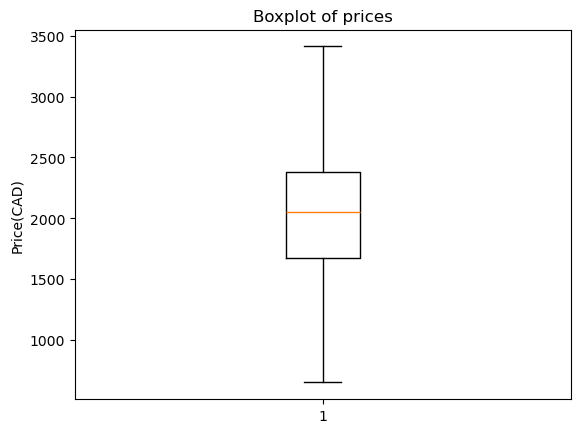

In [204]:
plt.figure()
plt.boxplot(df['price_cad'])
plt.title("Boxplot of prices")
plt.ylabel("Price(CAD)")
plt.show()

The box plot shows that median value is around 2000 CAD, upper quartile is around 2400 CAD, lower quartile is around 1650 CAD and also shows min value around 400 CAD and max value of 3400 CAD indicating the outliers in our dataset.

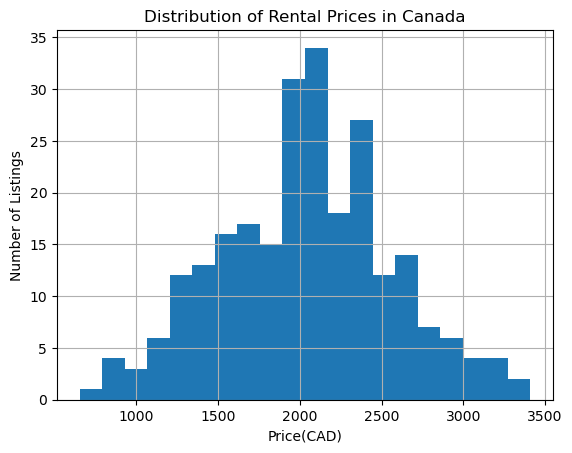

In [205]:


plt.figure()

plt.hist(df['price_cad'], bins=20)

plt.title("Distribution of Rental Prices in Canada")
plt.xlabel("Price(CAD)")
plt.ylabel("Number of Listings")
plt.grid(True)

plt.show()

The histogram shows the distribution of rental prices across Canadian cities. Most listings fall within a mid-range price band, indicating a concentration of moderately priced rentals. However, a few higher-priced outliers suggest the presence of premium properties, particularly in expensive markets. This indicates a right-skewed distribution where high-end rentals increase the overall average price.

Scatter Plot (Price vs Square Feet)

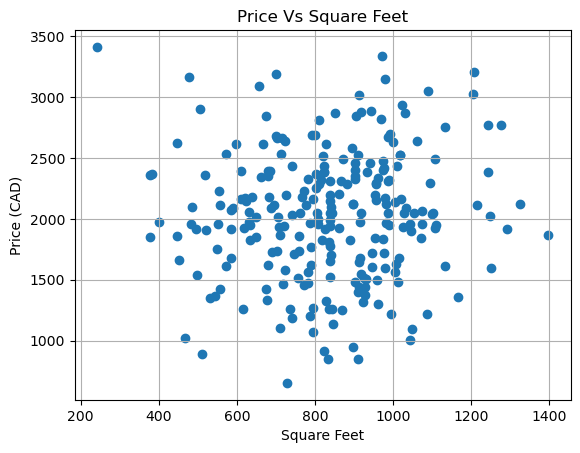

In [206]:
plt.figure()
plt.scatter(df['square_feet'], df['price_cad'])

plt.title("Price Vs Square Feet")
plt.xlabel("Square Feet")
plt.ylabel("Price (CAD)")
plt.grid(True)

plt.show()

The scatter plot illustrates a positive relationship between square footage and rental price, indicating that larger properties generally command higher rents. However, the spread of points suggests variability, meaning that factors such as location, amenities, and building type also significantly influence pricing beyond just size.

Bar Chart (Average Price by City)

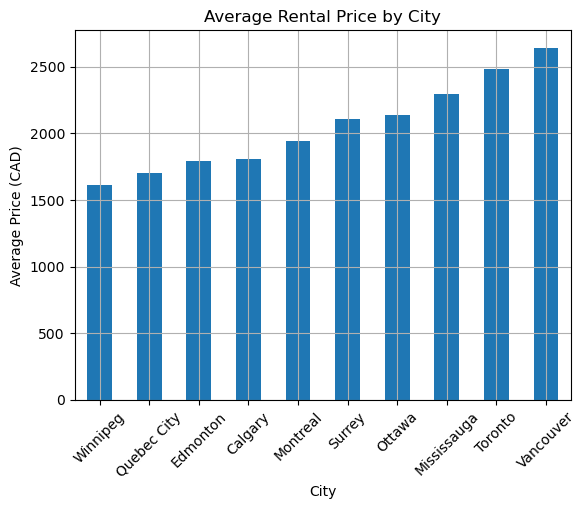

In [207]:
city_avg =df.groupby('cityname')['price_cad'].mean().sort_values()

plt.figure()

city_avg.plot(kind='bar')
plt.title("Average Rental Price by City")
plt.xlabel("City")
plt.ylabel("Average Price (CAD)")
plt.grid(True)

plt.xticks(rotation=45)

plt.show()


The bar chart highlights significant differences in rental prices across cities. Major metropolitan areas such as Toronto and Vancouver exhibit higher average rents compared to smaller cities like Winnipeg or Quebec City. This reflects real-world housing trends where demand, population density, and economic activity drive higher rental costs in urban centers.

The visual analysis reveals that the Canadian rental market is characterized by price variability driven by location and property size. Larger properties generally cost more, but city-level differences play a dominant role, with metropolitan areas commanding premium prices. The presence of outliers further indicates a segment of luxury rentals, contributing to a skewed price distribution.

Self-Assessment and Prespective

1. Limits, Flaws, and Biases of My Synthetic Dataset

The synthetic dataset I created has several limitations. First, it does not fully represent the real world complexity. The data was generated using random values and predefined ranges, which means it lacks realistic patterns such as seasonal price variations, neighborhood level differences, and market trends.

Another limitation is distribution bias. For example, I manually introduced fraud cases and outliers, but these may not reflect how fraud actually occurs in real housing markets. This could lead to a model that performs well on synthetic data but fails on the real world data.

Additionally, the dataset may suffer from sampling bias, as certain cities like Toronto and Vancouver were overrepresented when generating fraud cases. This could unintentionally bias the model to associate fraud more strongly with specific locations.

Overall, while the dataset is useful for testing logic and pipeline design, it is not fully reliable for real-world predictions.

2. Data Privacy and Ethical Concerns

If this pipeline were applied to real Canadian renters data, there would be serious privacy and ethical considerations.

First, renter data may include personally identifiable information (PII) such as names, addresses, income, or contact details. This data must be protected according to privacy laws in Canada.

Second, there is a risk of algorithmic bias and discrimination. For example, if the model indirectly learns patterns based on location or socioeconomic indicators, it could unfairly flag certain groups or neighborhoods as fraudulent or high risk.

Third, transparency is important. Users and stakeholders should understand how decisions are being made. A lack of explainability could lead to mistrust in the system.

To address these concerns, I would need to:
Remove or anonymize sensitive data
Ensure compliance with Canadian privacy regulations
Regularly audit the model for bias and fairness

3. Impact on the Operations Team

If the pipeline were deployed with biased data or without proper privacy safeguards, it could negatively impact the Operations team.

For example:
False positives in fraud detection could cause legitimate listings to be flagged, leading to unnecessary investigations and delays
Biased outputs could result in unfair treatment of certain regions or customers
Privacy violations could expose the organization to legal risks and damage its reputation.

This would increase workload, reduce trust in the system, and potentially lead to poor decision making. Therefore, ensuring data quality and ethical compliance is critical before deployment.


4. Reflection on Python Memory Management and OOP Design

Through this project, I learned that my initial design could be improved in terms of efficiency and scalability.

One limitation was converting DataFrame rows into individual objects, which can be memory-intensive and slow for large datasets. In a real-world pipeline, it would be more efficient to use vectorized operations in Pandas instead of iterating through rows.

In terms of OOP design, while I implemented classes, getters, and setters, some parts of the design were overly complex for the task. 
A better approach would be:
Use OOP for high-level pipeline structure
Use Pandas for data processing tasks
Avoid unnecessary object creation for large datasets

If I were to rebuild this pipeline, I would:
Focus more on efficient data handling using vectorization
Design modular classes for cleaning, transformation, and modeling
Optimize memory usage by avoiding redundant copies of data

Final Thoughts:
This project helped me understand the gap between a working prototype and a real world system. While my pipeline functions correctly on synthetic data, deploying it in a real environment would require significant improvements in data quality, ethical considerations, and system efficiency. 
This experience has improved my understanding of both technical implementation and responsible data engineering practices


Evaluation of GenAI Output in Data Generation
During the data generation phase, I used chatgpt to help simulate a synthetic real estate dataset. While this approach was useful for quickly creating large volumes of data, it also introduced several assumptions and quality concerns that must be critically evaluated.

One key assumption is that the generated data reflects real world distributions. However, GenAI does not inherently understand actual housing market dynamics unless explicitly guided with real statistical constraints. 
As a result:
Price ranges, property sizes, and relationships between variables may not accurately reflect real Canadian housing markets
Fraud patterns were artificially injected based on simplified logic (e.g., low price and high area), which may not capture the complexity of real fraud cases
Geographic patterns (e.g., Toronto and Vancouver being high value markets) were assumed rather than validated with real data

These assumptions can lead to unrealistic correlations and oversimplified patterns.

Although the dataset appeared structured, there are important quality limitations:
Lack of realism: The data does not capture real world noise such as market fluctuations, seasonal trends, or economic factors
Over simplification: Relationships between variables (e.g., price and area) are too clean or artificially manipulated
Limited variability: Random generation may fail to capture rare but meaningful edge cases
Bias introduction: Fraud cases and outliers were manually injected, which could bias the model toward detecting only those specific patterns

As a result, the dataset is useful for testing functionality but not for validating real-world performance.

Use of GenAI Tools:
During the development of this project, limited use of Generative AI (GenAI) tools specifically chatGpt was made to support the initial stages of brainstorming and dataset creation.
GenAI assistance was used in the following ways:
Idea Generation:
To brainstorm approaches for structuring a synthetic real estate dataset, including identifying relevant attributes such as price, area, location, and property features.
Synthetic Data Creation:
To help generate a preliminary version of a synthetic dataset in CSV format. This dataset was later modified, cleaned, and validated manually to better align with the project requirements.

This project reflects my own understanding and application of Python, data processing, and object oriented design principles. 
GenAI tools were used only as a supplementary aid for ideation and initial data generation, in accordance with academic integrity guidelines.